# 📊 Billings Dataset - Exploratory Data Analysis (EDA)

This notebook performs comprehensive EDA on the **cleaned** billings dataset to uncover patterns, distributions, and insights relevant to churn prediction.

**Objective**: Identify customer characteristics and billing patterns that drive churn 14 days before subscription renewal.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Load cleaned billings data
billings = pd.read_csv('../../data/cleaned/billings_cleaned.csv', low_memory=False)

# Parse date columns
date_cols = ['prospect_renewal_date', 'registration_date', 'closed_date']
for col in date_cols:
    if col in billings.columns:
        billings[col] = pd.to_datetime(billings[col], errors='coerce')

print(f'Shape: {billings.shape}')
print(f'Columns: {list(billings.columns)}')

Shape: (113766, 35)
Columns: ['co_ref', 'renewal_month', 'sustainability_score', 'total_renewal_score_new', 'auto_renewal_score', 'status_scores', 'anchoring_score', 'tenure_scores', 'current_anchorings', 'payment_timeframe', 'registration_date', 'proforma_account_stage', 'proforma_audit_status', 'current_auto_renewal_flag', 'current_world_pay_token', 'renewal_score_at_release', 'proforma_membership_status', 'proforma_approved_lists', 'tenure_years', 'band', 'prospect_renewal_date', 'closed_date', 'prospect_status', 'total_net_paid', 'prospect_outcome', 'payment_method', 'amount', 'connection_group', 'tenure_group', '#_of_connection', 'last_band', 'last_connections', 'renewal_year', 'last_years_price', 'price_change']


In [2]:
billings.info()

<class 'pandas.DataFrame'>
RangeIndex: 113766 entries, 0 to 113765
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   co_ref                      113766 non-null  str           
 1   renewal_month               113766 non-null  str           
 2   sustainability_score        113766 non-null  float64       
 3   total_renewal_score_new     113766 non-null  float64       
 4   auto_renewal_score          113766 non-null  int64         
 5   status_scores               113766 non-null  int64         
 6   anchoring_score             113766 non-null  float64       
 7   tenure_scores               113766 non-null  float64       
 8   current_anchorings          113766 non-null  int64         
 9   payment_timeframe           113766 non-null  float64       
 10  registration_date           112794 non-null  datetime64[us]
 11  proforma_account_stage      113766 non-null  str  

In [3]:
billings.describe()

,sustainability_score,total_renewal_score_new,auto_renewal_score,status_scores,anchoring_score,tenure_scores,current_anchorings,payment_timeframe,registration_date,renewal_score_at_release,...,tenure_years,prospect_renewal_date,closed_date,total_net_paid,amount,#_of_connection,last_connections,renewal_year,last_years_price,price_change
count,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,112794,113766.000000,...,113766.000000,113766,113766,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000,113766.000000
mean,8.613320,41.904862,8.471960,7.097217,8.704182,9.018182,3.102324,-6.547316,2017-10-14 14:14:16.768977,25.774960,...,6.842897,2024-08-19 02:27:18.521175,2024-08-16 00:36:21.150783,1058.690133,1087.292319,3.222228,2.090853,2024.179113,582.684886,476.005247
min,8.000000,30.500000,8.000000,0.000000,7.500000,7.000000,0.000000,-1081.000000,2000-01-01 00:00:00,15.500000,...,0.000000,2023-01-01 00:00:00,2021-09-15 00:00:00,0.000000,0.000000,0.000000,0.000000,2023.000000,0.000000,-3238.000000
25%,8.000000,41.000000,8.000000,7.000000,8.500000,8.500000,1.000000,-13.000000,2014-05-02 00:00:00,24.500000,...,2.000000,2023-10-28 00:00:00,2023-10-27 00:00:00,684.000000,699.000000,1.000000,0.000000,2023.000000,0.000000,65.000000
50%,8.000000,43.500000,8.000000,9.000000,8.500000,9.500000,1.000000,0.000000,2019-02-12 00:00:00,26.000000,...,5.000000,2024-08-24 00:00:00,2024-08-20 00:00:00,919.000000,924.000000,1.000000,0.000000,2024.000000,579.000000,308.400000
75%,9.500000,45.000000,9.000000,9.000000,9.500000,9.500000,3.000000,0.000000,2022-03-23 00:00:00,27.500000,...,10.000000,2025-06-10 00:00:00,2025-06-09 00:00:00,1214.000000,1244.000000,3.000000,2.000000,2025.000000,934.000000,749.000000
max,9.500000,46.500000,9.000000,9.000000,9.500000,9.500000,209.000000,482.000000,2026-03-24 00:00:00,28.200000,...,26.000000,2026-05-31 00:00:00,2026-03-16 00:00:00,18326.000000,17877.000000,197.000000,197.000000,2026.000000,12616.000000,9346.000000
std,0.692147,4.395806,0.499215,3.347584,0.735701,0.610783,6.485866,25.960106,NaN,1.886469,...,5.370246,NaN,NaN,636.291668,651.869848,6.551785,5.584893,0.948112,620.701351,519.723789


## 2. Missing Values Analysis

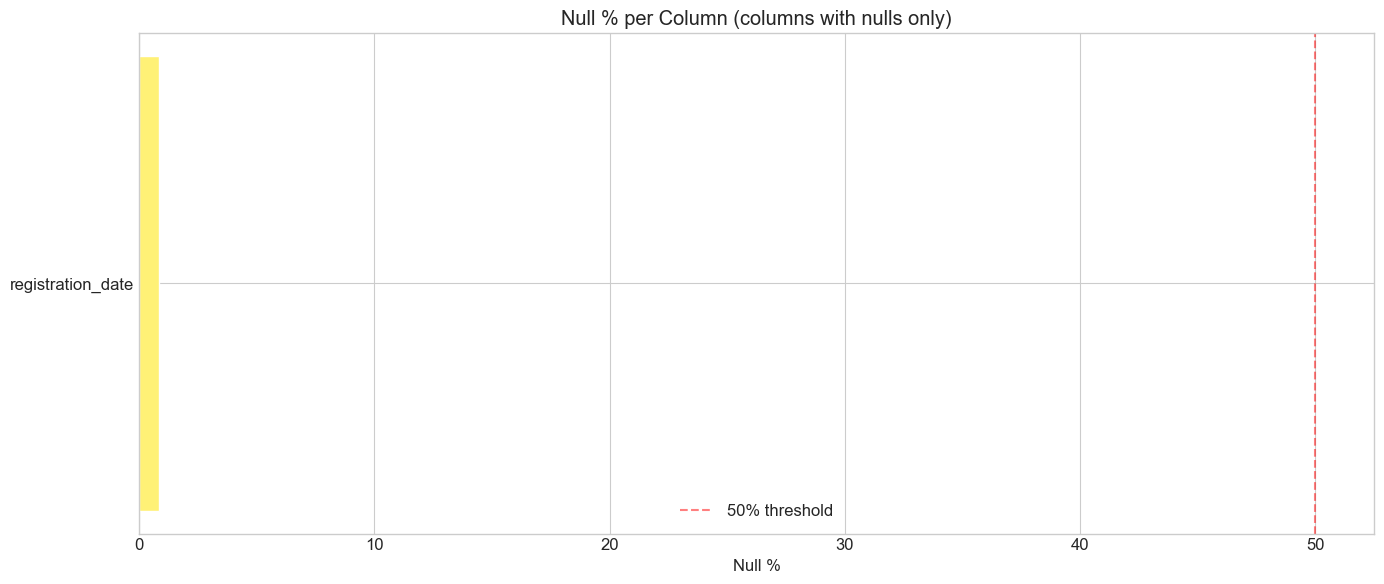

Red = >50% null | Orange = >10% | Yellow = <10%

Missing values summary:
                   null_count  null_pct
registration_date         972      0.85


In [4]:
null_df = pd.DataFrame({
    'dtype': billings.dtypes,
    'null_count': billings.isnull().sum(),
    'null_pct': (billings.isnull().sum() / len(billings) * 100).round(2)
}).sort_values('null_pct', ascending=False)

# Show columns with nulls
cols_with_nulls = null_df[null_df['null_pct'] > 0]
if len(cols_with_nulls) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    null_vals = cols_with_nulls['null_pct'].values
    colors = ['#E57373' if v > 50 else '#FF9800' if v > 10 else '#FFF176' for v in null_vals]
    ax.barh(cols_with_nulls.index[::-1], null_vals[::-1], color=colors[::-1], edgecolor='white')
    ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax.set_xlabel('Null %')
    ax.set_title('Null % per Column (columns with nulls only)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('Red = >50% null | Orange = >10% | Yellow = <10%')
else:
    print('No missing values in the cleaned dataset!')

print('\nMissing values summary:')
print(cols_with_nulls[['null_count', 'null_pct']])

## 3. Target Variable Analysis (Prospect_Outcome / Churn)

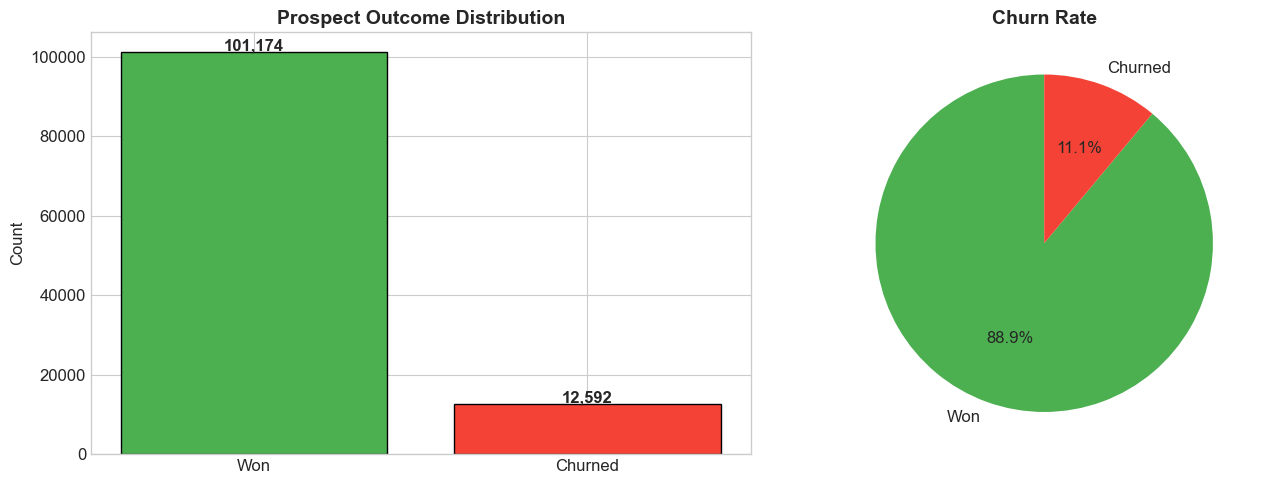


Churn Rate: 11.1%
Win Rate: 88.9%


In [5]:
# Create binary churn label
billings['is_churned'] = (billings['prospect_outcome'] == 'Churned').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
outcome_counts = billings['prospect_outcome'].value_counts()
colors_target = ['#4CAF50', '#F44336']
axes[0].bar(outcome_counts.index, outcome_counts.values, color=colors_target, edgecolor='black')
axes[0].set_title('Prospect Outcome Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(outcome_counts.index, outcome_counts.values)):
    axes[0].text(i, val + 500, f'{val:,}', ha='center', fontweight='bold')

# Percentage pie chart
outcome_pct = billings['prospect_outcome'].value_counts(normalize=True) * 100
axes[1].pie(outcome_pct.values, labels=outcome_pct.index, autopct='%1.1f%%',
            colors=colors_target, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../reports/figures/billings_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nChurn Rate: {outcome_pct.get("Churned", 0):.1f}%')
print(f'Win Rate: {outcome_pct.get("Won", 0):.1f}%')

## 4. Numerical Features Distribution

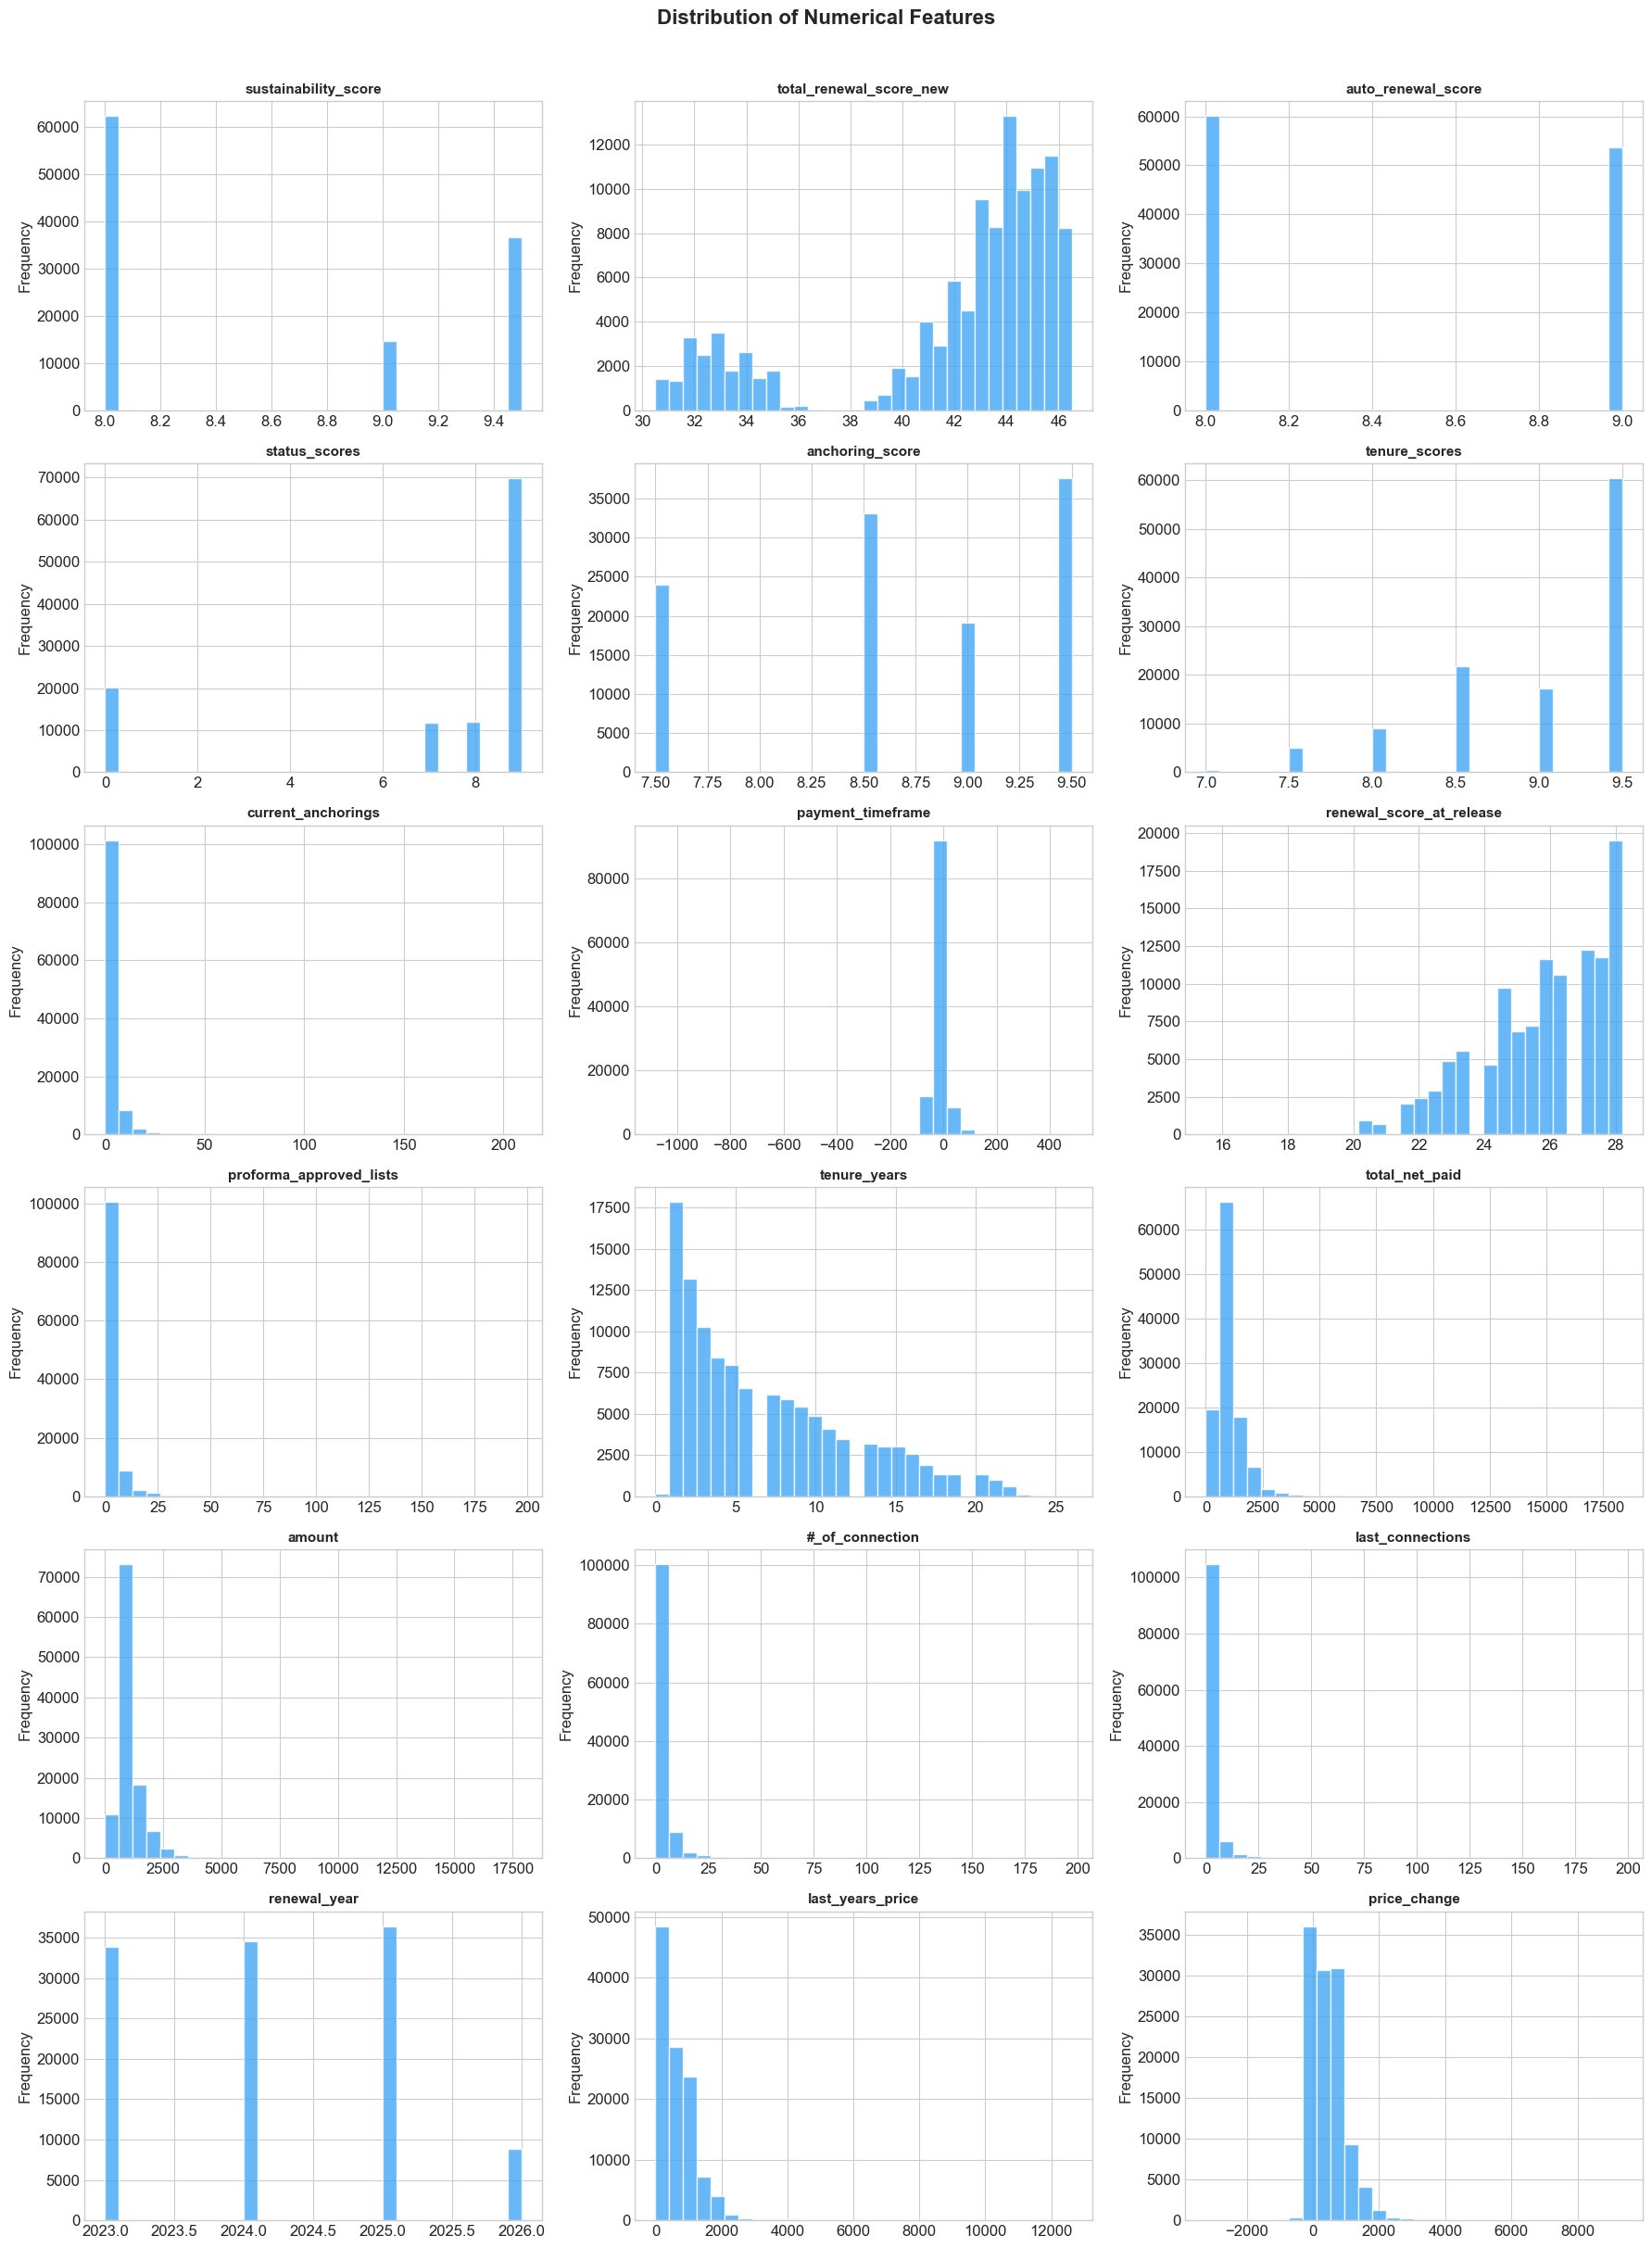

In [6]:
numeric_cols = billings.select_dtypes(include=[np.number]).columns.tolist()
# Remove the target and id-like columns
numeric_cols = [c for c in numeric_cols if c not in ['is_churned']]

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    billings[col].hist(bins=30, ax=ax, color='#42A5F5', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/billings_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Numerical Features vs Churn (Box Plots)

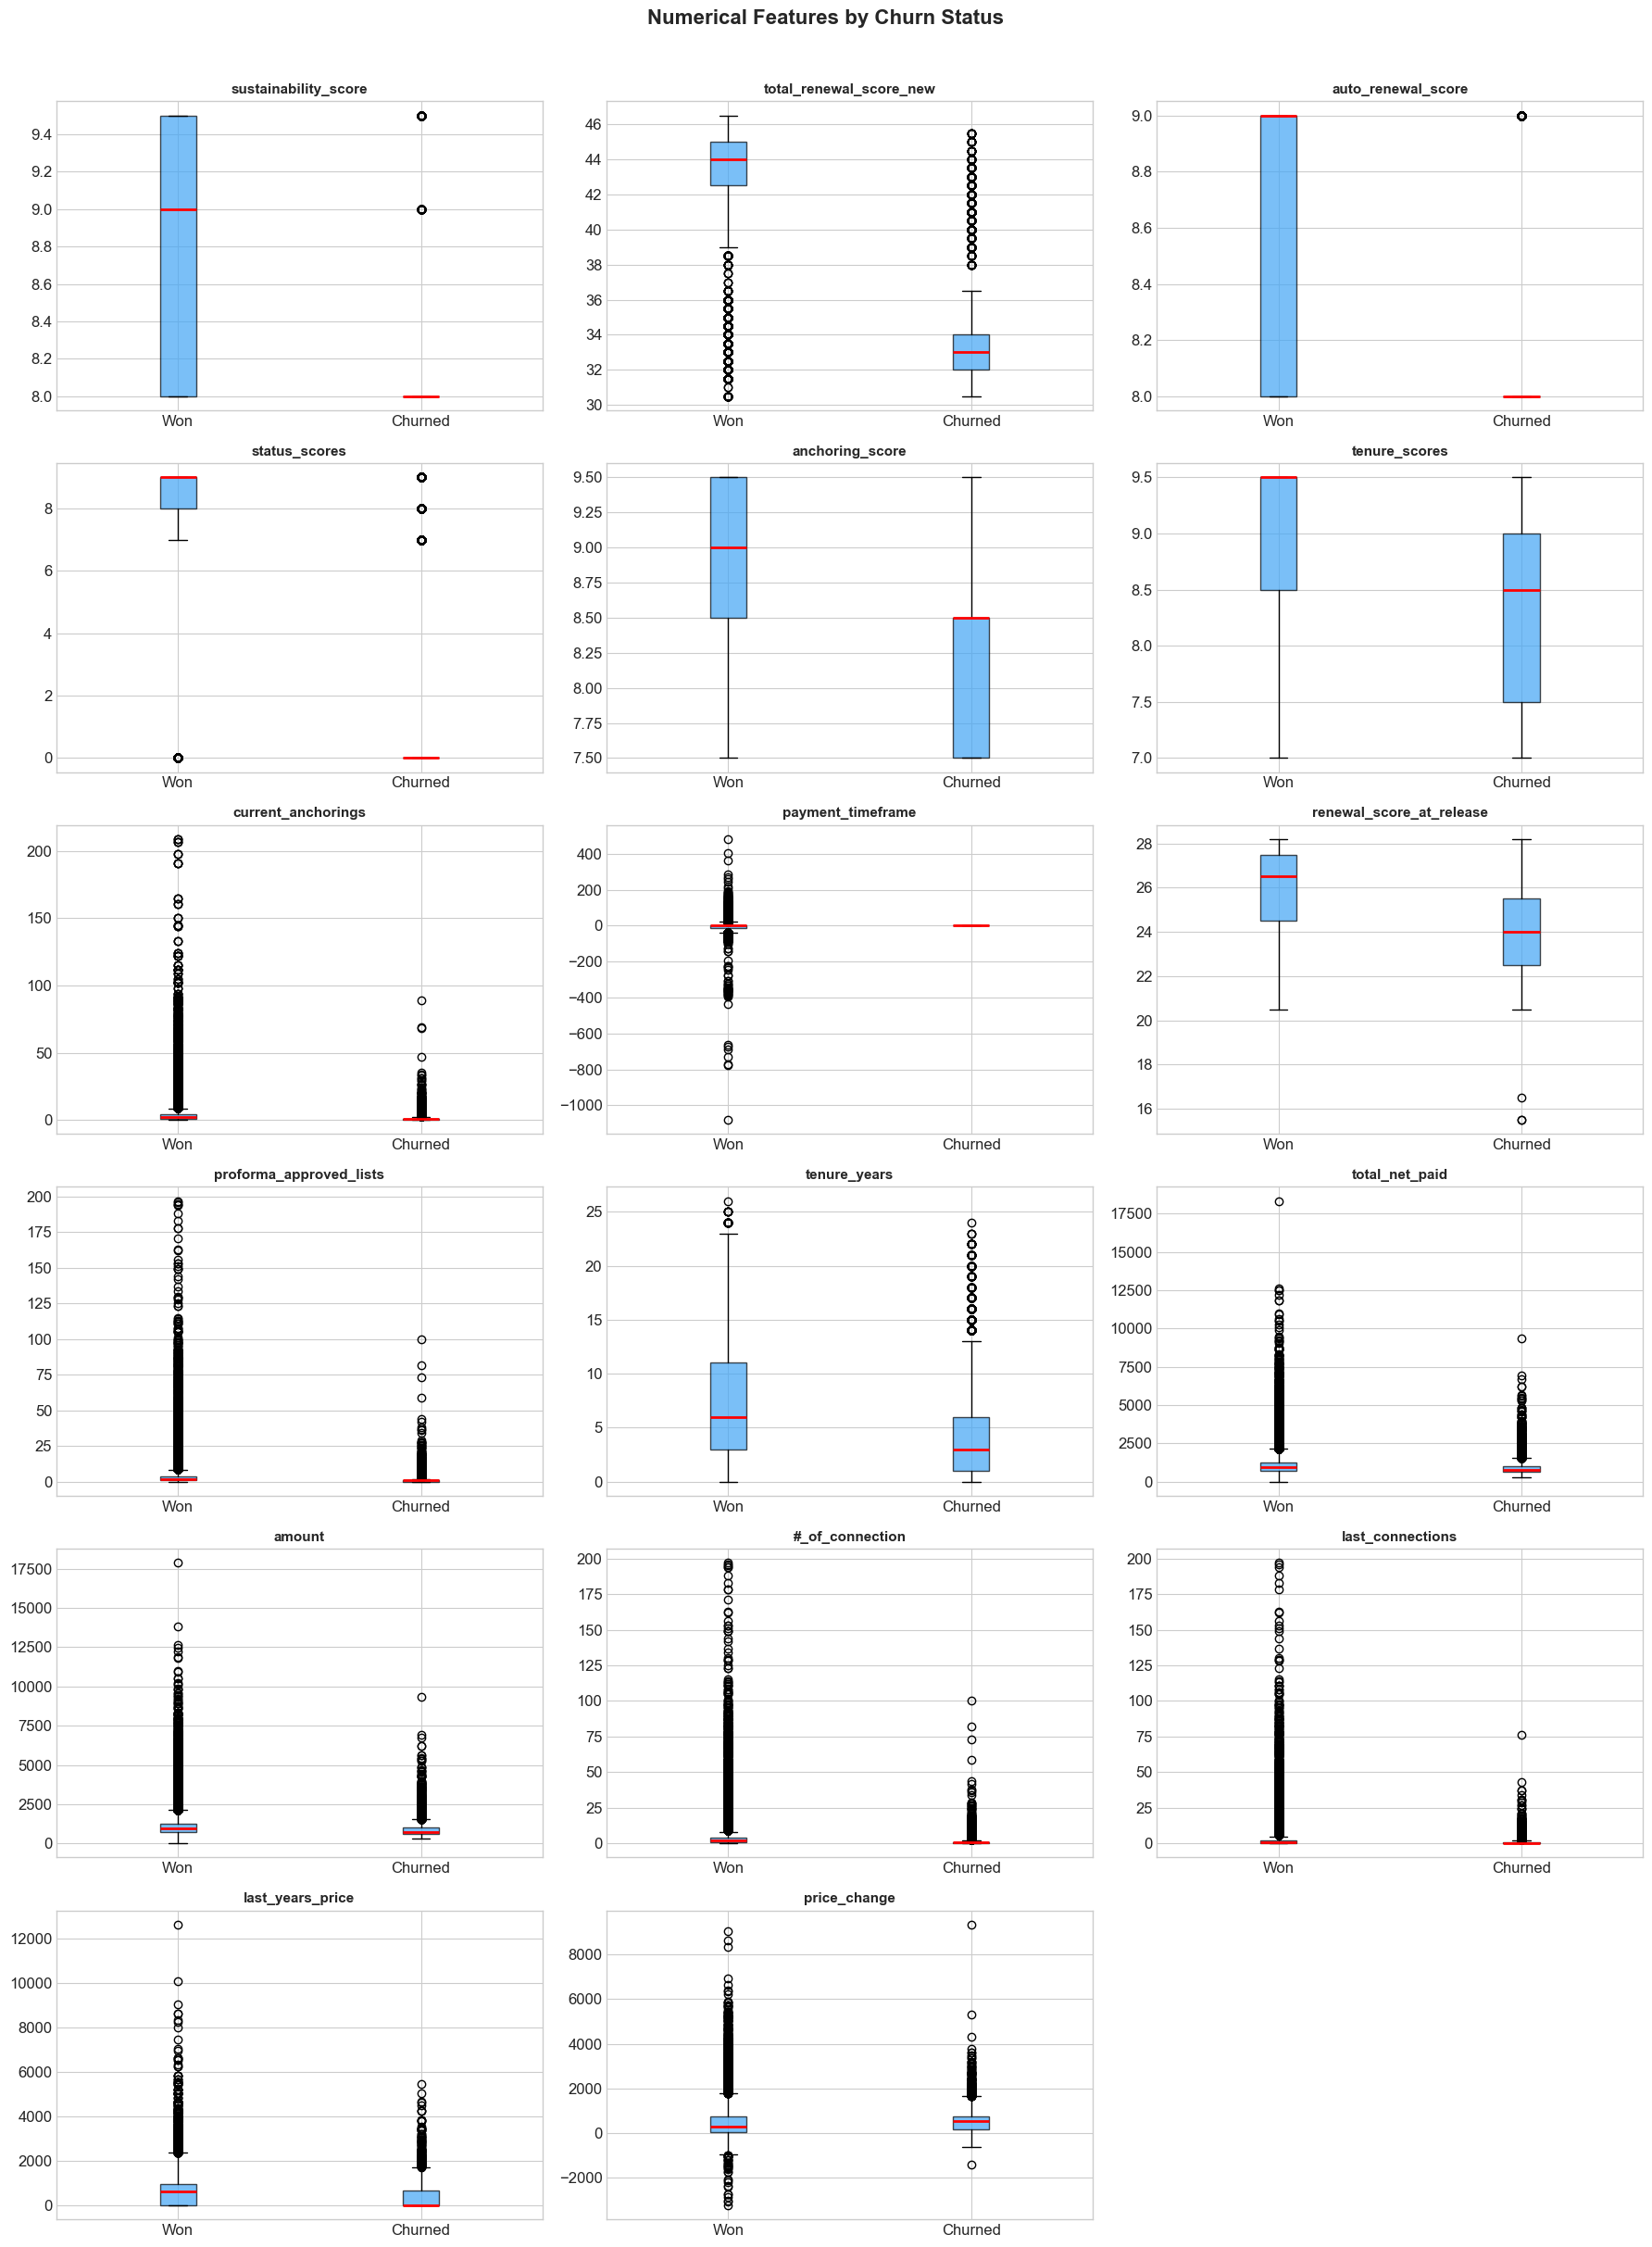

In [7]:
key_numeric = [c for c in numeric_cols if c not in ['renewal_year', 'renewal_month']]

n_cols_plot = 3
n_rows_plot = (len(key_numeric) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    ax = axes[i]
    won_data = billings[billings['prospect_outcome'] == 'Won'][col].dropna()
    churned_data = billings[billings['prospect_outcome'] == 'Churned'][col].dropna()
    ax.boxplot([won_data, churned_data],
               labels=['Won', 'Churned'],
               patch_artist=True,
               boxprops=dict(facecolor='#42A5F5', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=11, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Churn Status', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/billings_boxplot_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Categorical Features Analysis

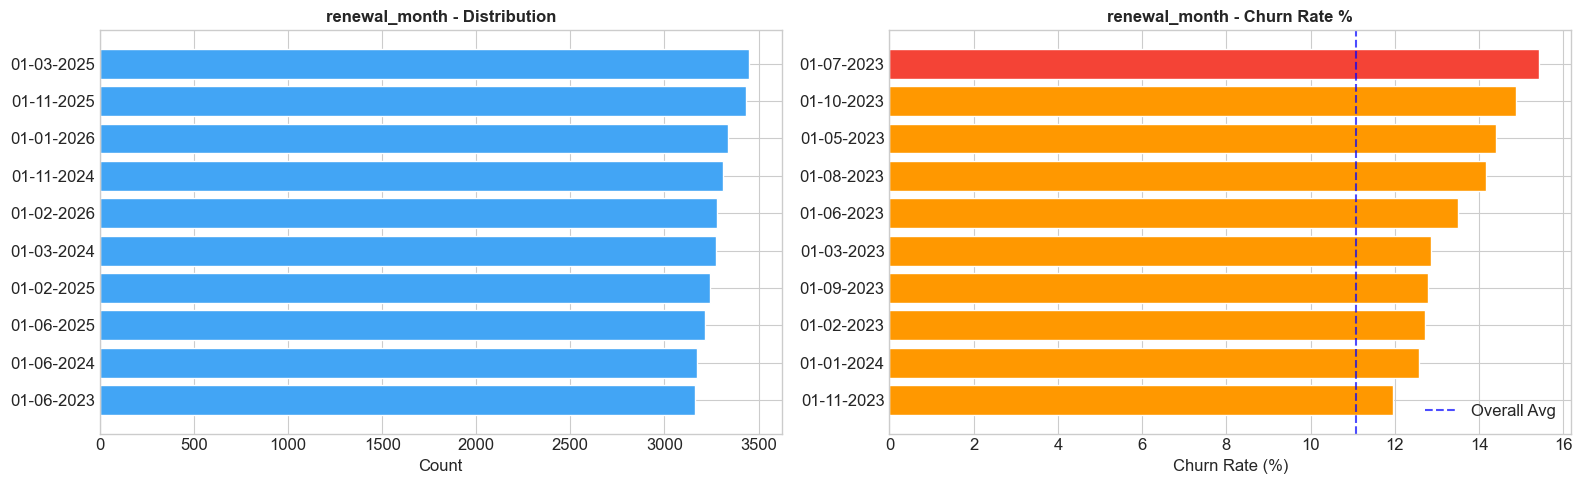

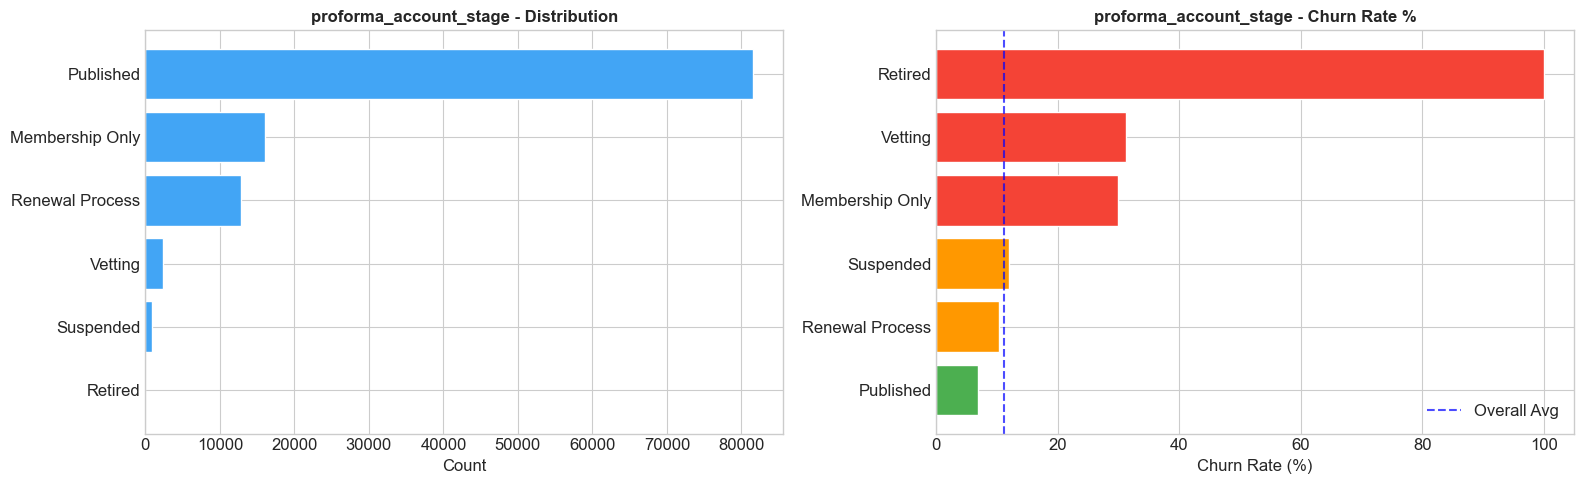

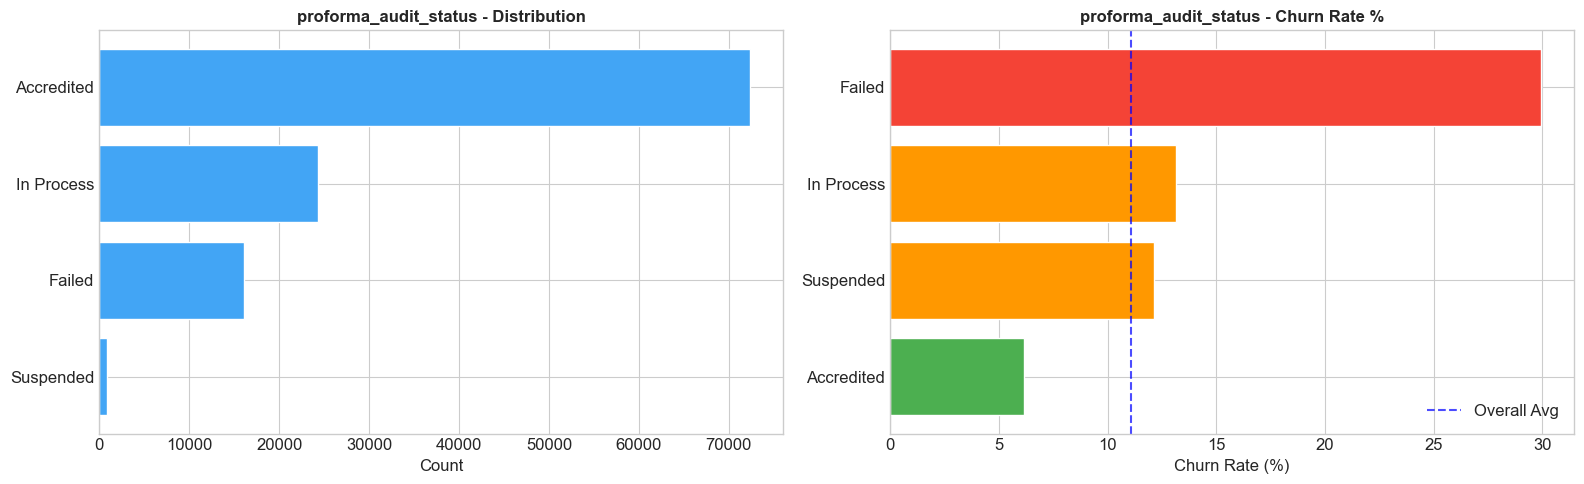

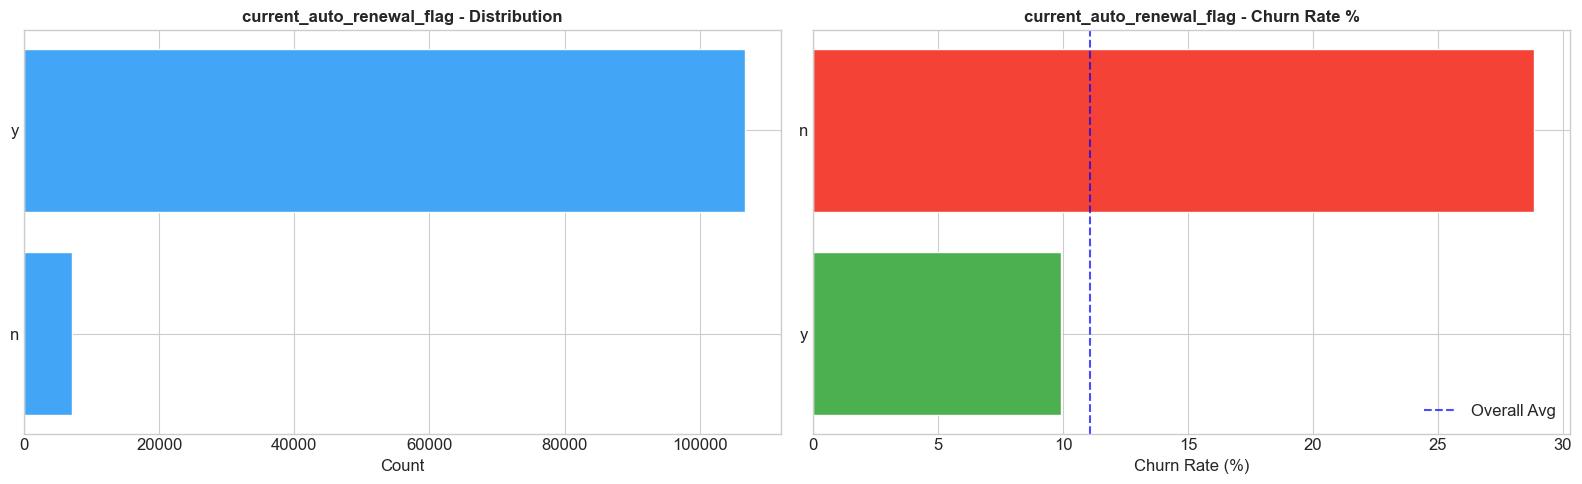

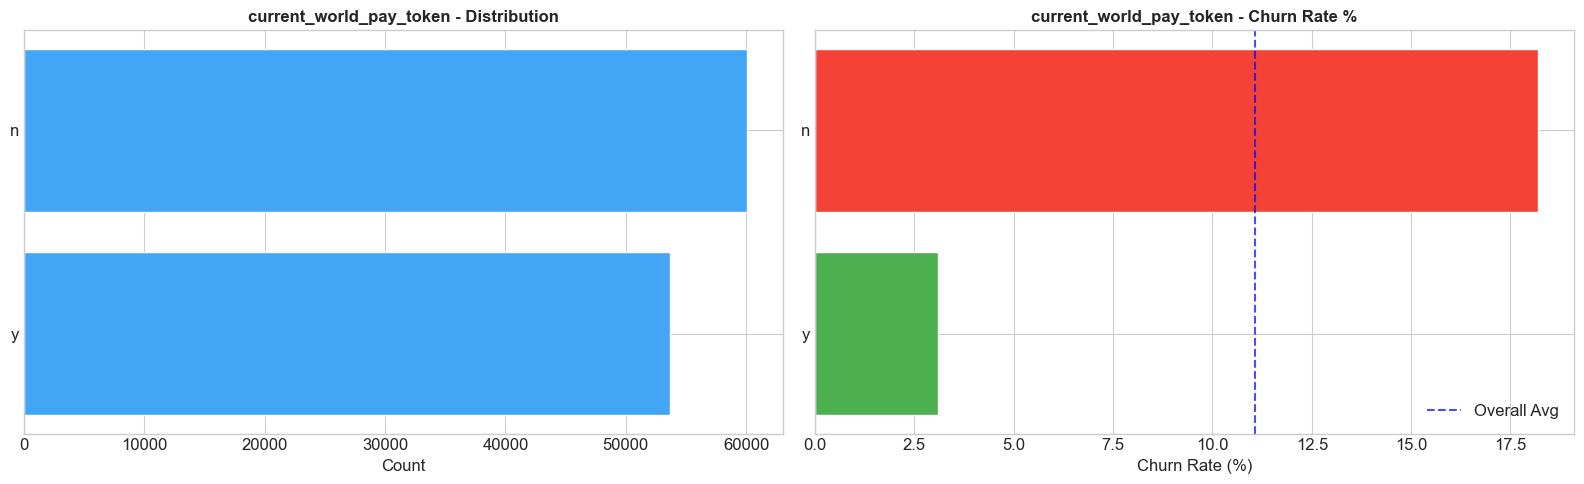

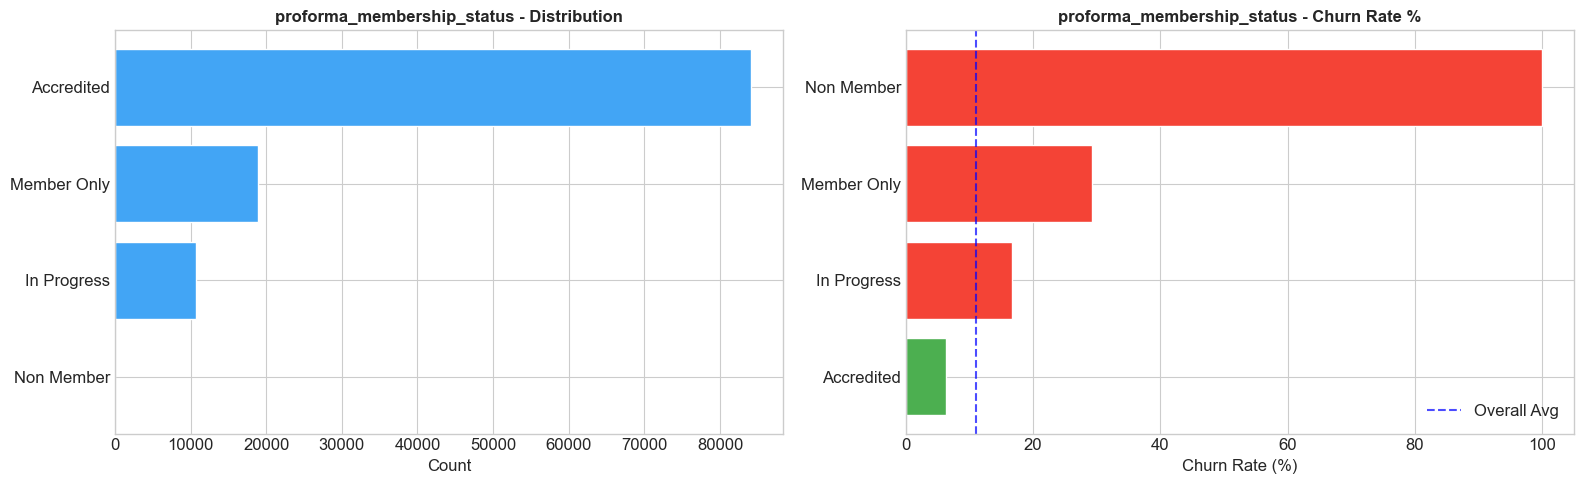

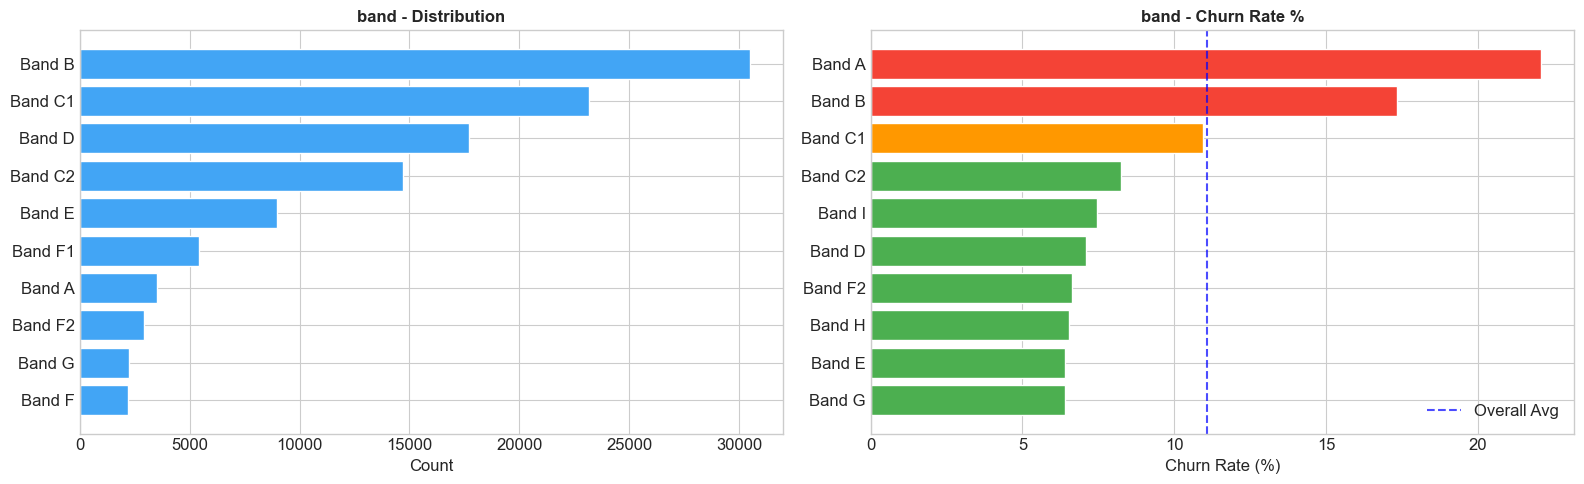

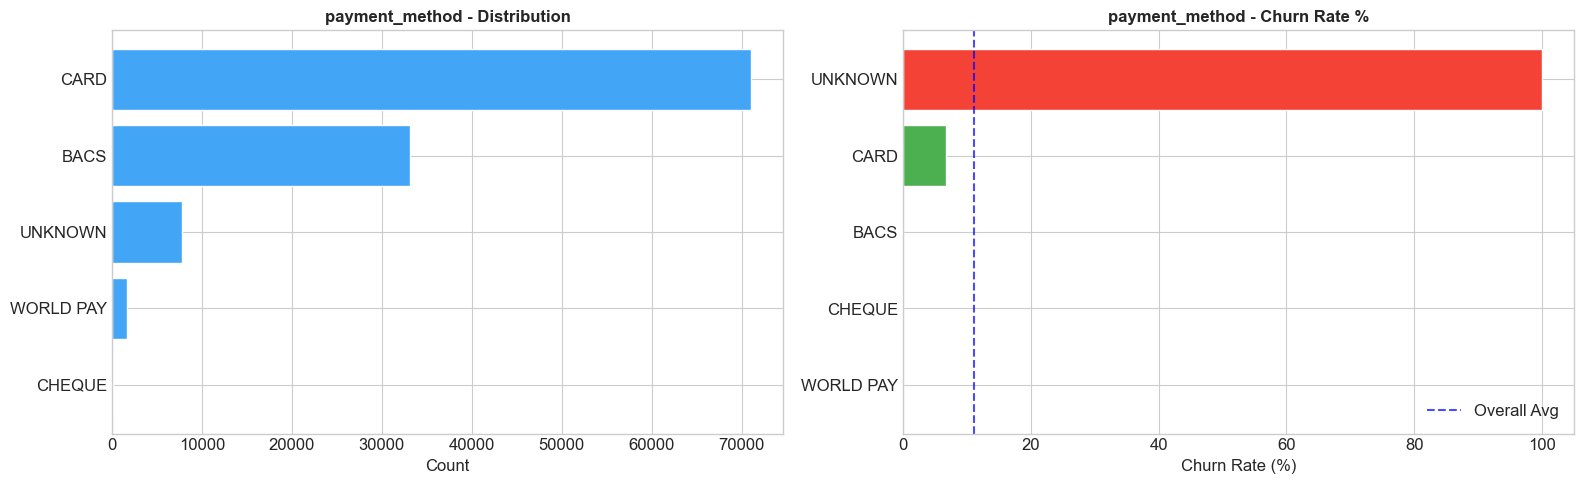

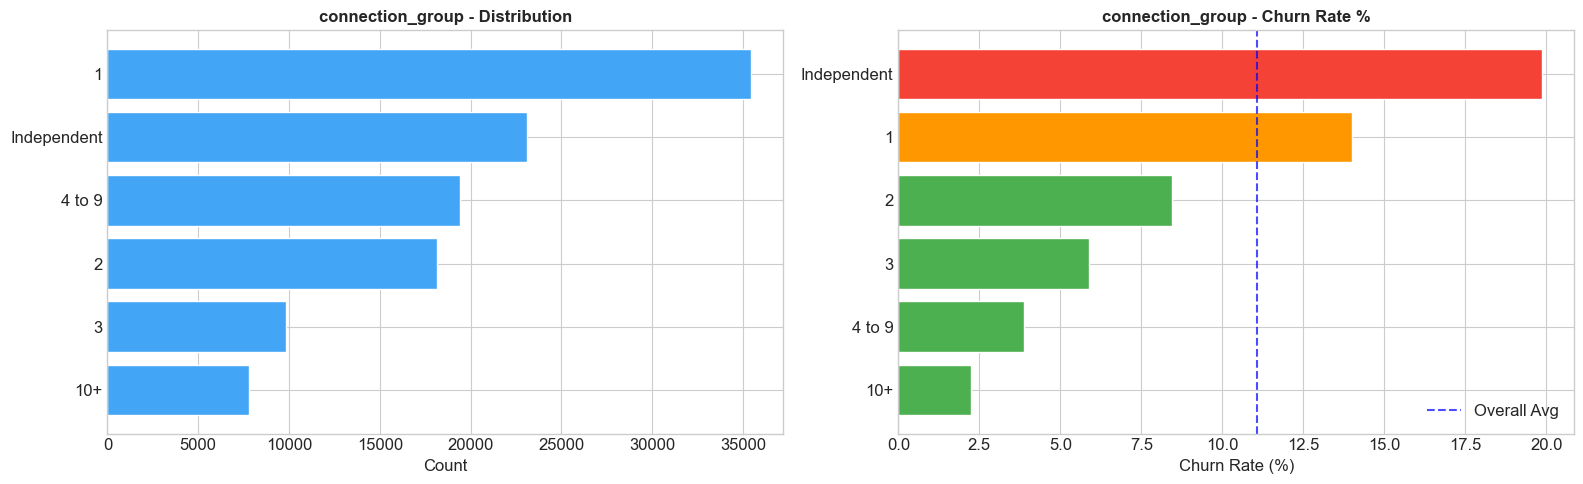

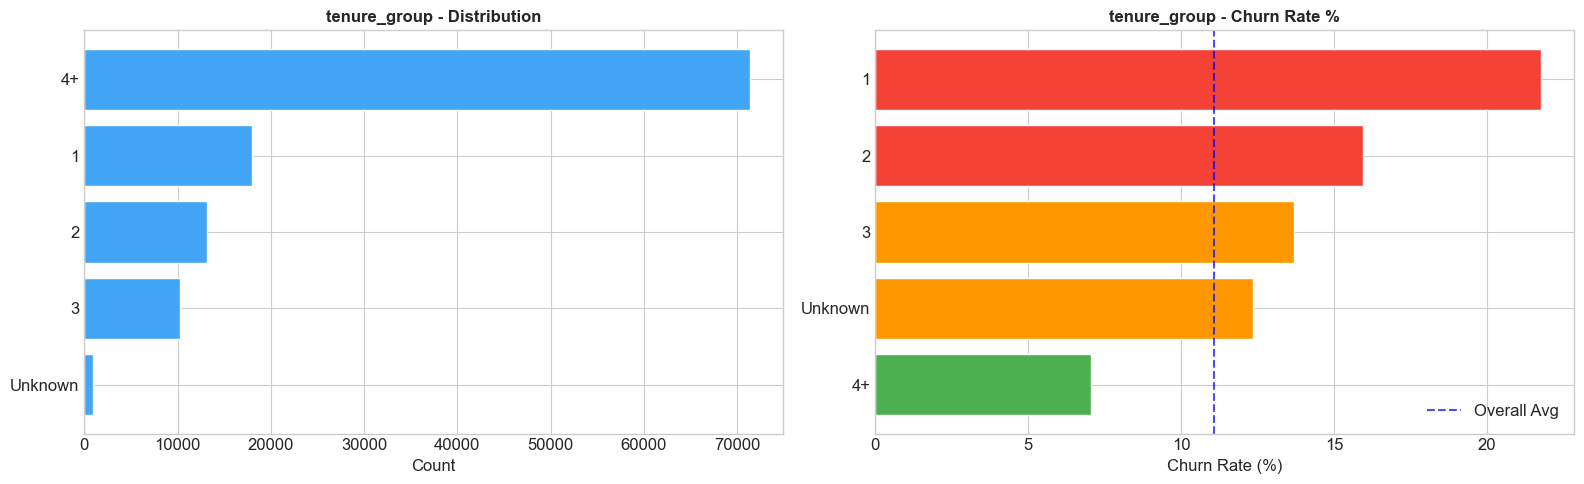

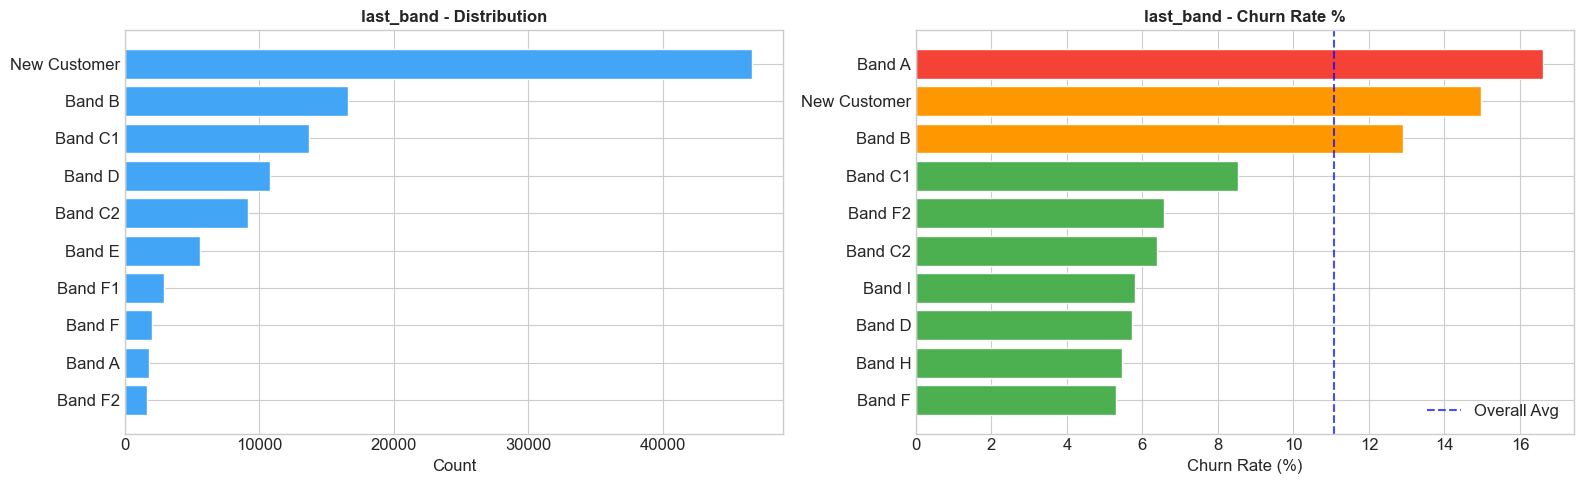

In [8]:
cat_cols = billings.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['co_ref', 'prospect_outcome', 'prospect_status']]

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Overall distribution
    value_counts = billings[col].value_counts().head(10)
    axes[0].barh(value_counts.index[::-1], value_counts.values[::-1], color='#42A5F5', edgecolor='white')
    axes[0].set_title(f'{col} - Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Count')
    
    # Churn rate per category
    churn_by_cat = billings.groupby(col)['is_churned'].mean().sort_values(ascending=False).head(10)
    colors_churn = ['#F44336' if v > 0.15 else '#FF9800' if v > 0.10 else '#4CAF50' for v in churn_by_cat.values]
    axes[1].barh(churn_by_cat.index[::-1], (churn_by_cat.values * 100)[::-1], color=colors_churn[::-1], edgecolor='white')
    axes[1].set_title(f'{col} - Churn Rate %', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Churn Rate (%)')
    axes[1].axvline(billings['is_churned'].mean() * 100, color='blue', linestyle='--', alpha=0.7, label='Overall Avg')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## 7. Correlation Heatmap

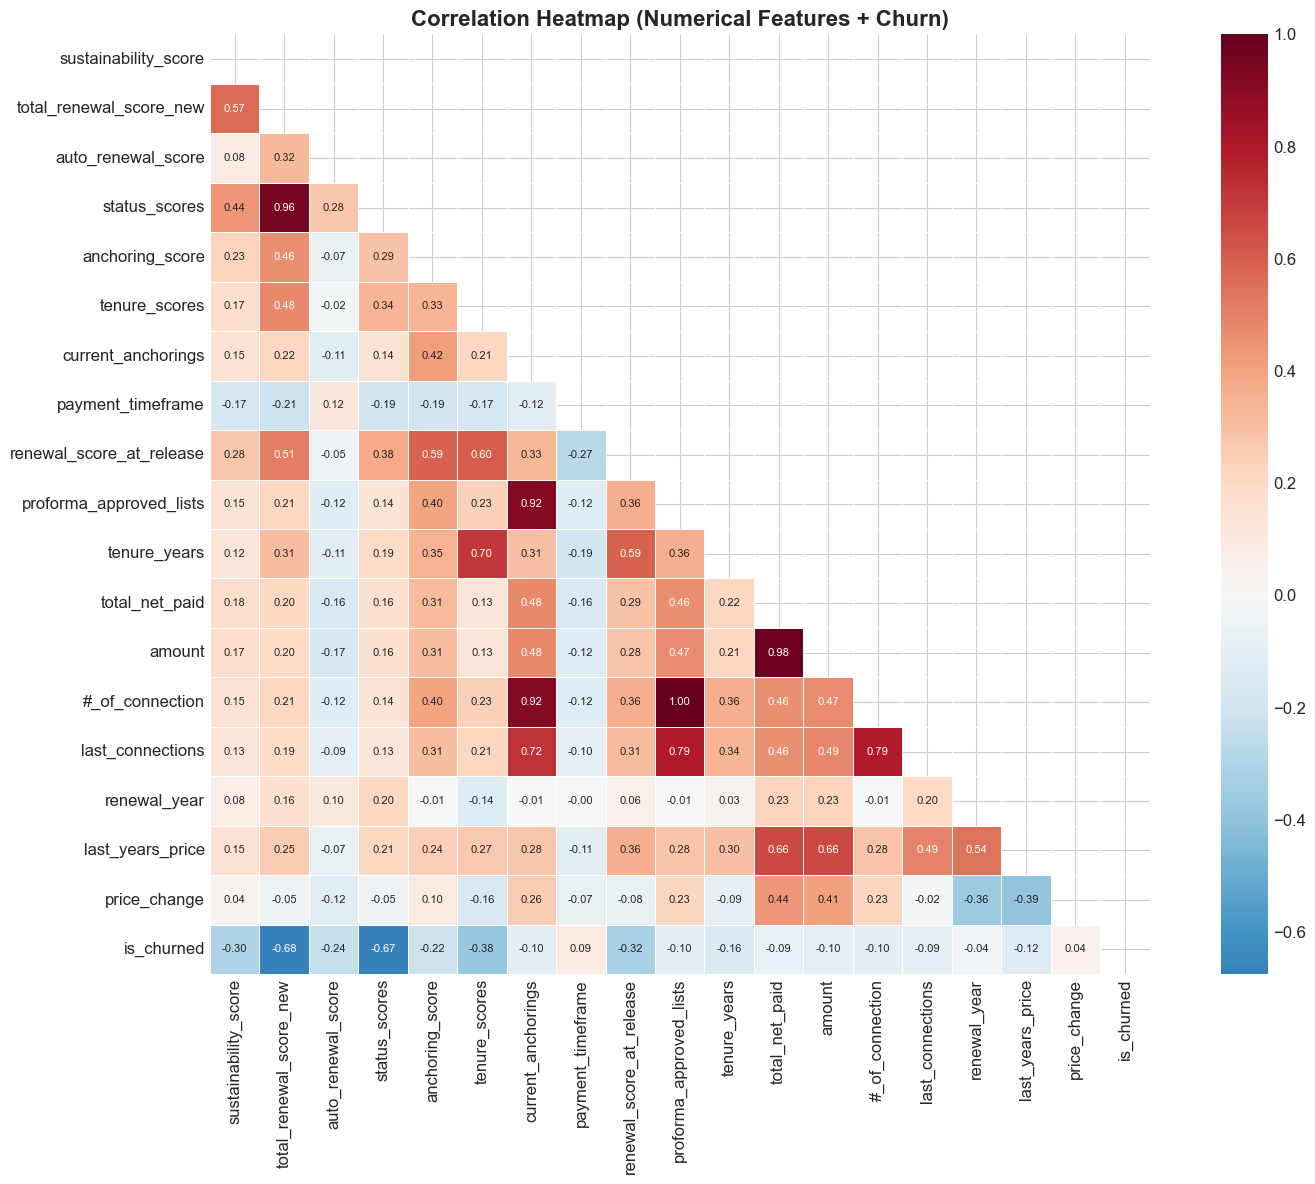

In [9]:
# Select numeric columns for correlation
corr_cols = [c for c in numeric_cols if billings[c].notna().sum() > len(billings) * 0.5]
corr_cols.append('is_churned')

corr_matrix = billings[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap (Numerical Features + Churn)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/billings_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

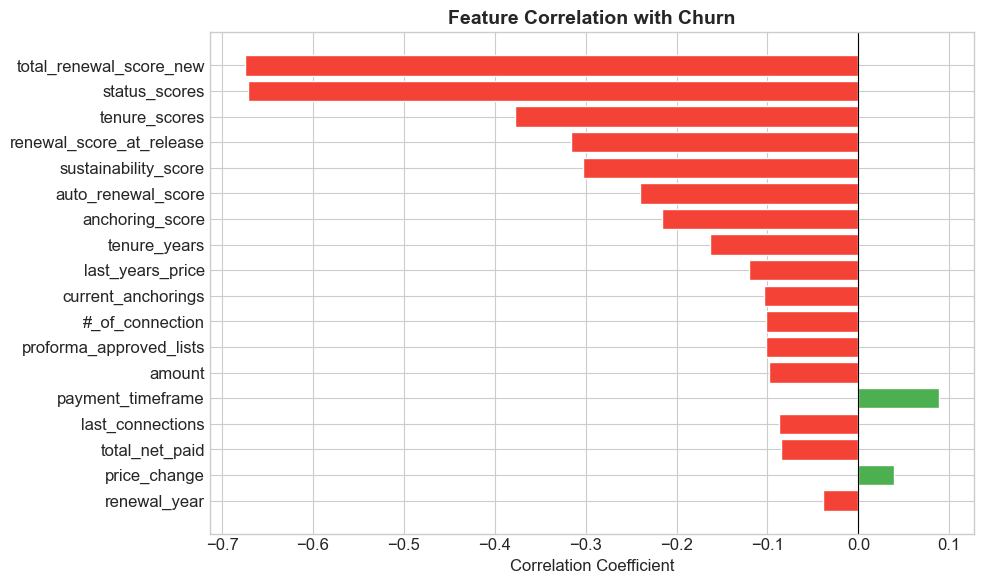


Correlations with Churn (sorted by absolute value):
total_renewal_score_new    -0.675259
status_scores              -0.671687
tenure_scores              -0.378131
renewal_score_at_release   -0.316235
sustainability_score       -0.303422
auto_renewal_score         -0.240029
anchoring_score            -0.216098
tenure_years               -0.162881
last_years_price           -0.120343
current_anchorings         -0.104154
#_of_connection            -0.101728
proforma_approved_lists    -0.101728
amount                     -0.098729
payment_timeframe           0.088976
last_connections           -0.087414
total_net_paid             -0.085288
price_change                0.039308
renewal_year               -0.038693


In [10]:
# Top correlations with churn
churn_corr = corr_matrix['is_churned'].drop('is_churned').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_corr = ['#F44336' if v < 0 else '#4CAF50' for v in churn_corr.values]
ax.barh(churn_corr.index[::-1], churn_corr.values[::-1], color=colors_corr[::-1], edgecolor='white')
ax.set_title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../../reports/figures/billings_churn_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelations with Churn (sorted by absolute value):')
print(churn_corr.to_string())

## 8. Temporal Analysis - Churn by Renewal Year

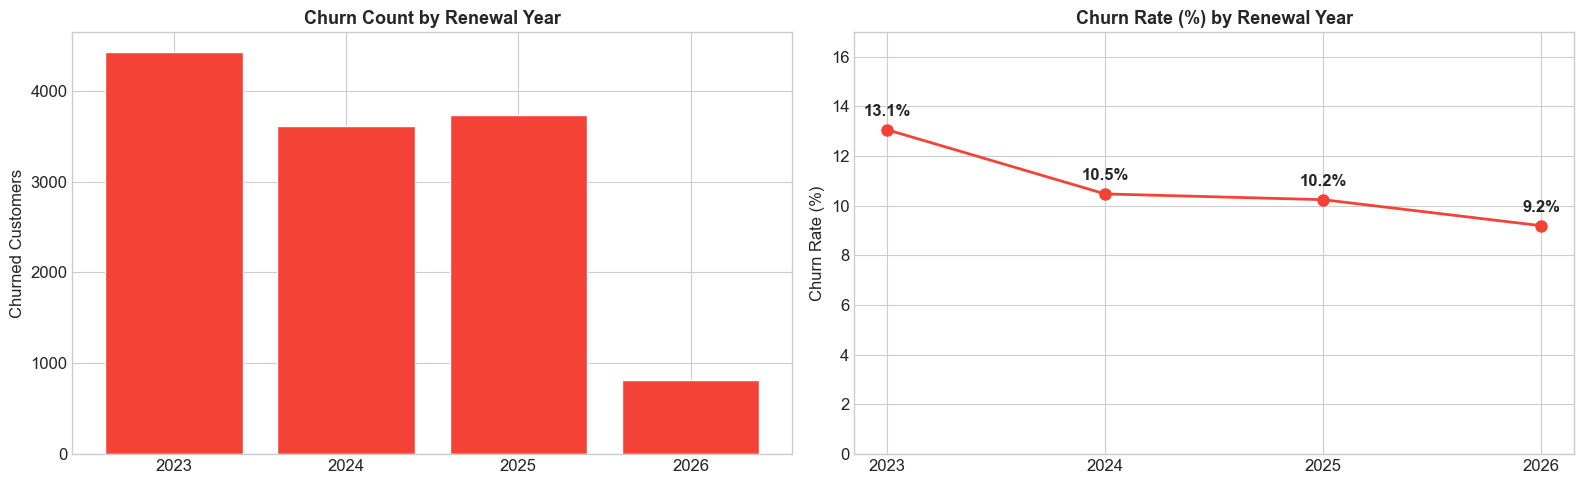

In [11]:
if 'renewal_year' in billings.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Churn count by year
    churn_by_year = billings.groupby('renewal_year')['is_churned'].sum()
    axes[0].bar(churn_by_year.index.astype(str), churn_by_year.values, color='#F44336', edgecolor='white')
    axes[0].set_title('Churn Count by Renewal Year', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Churned Customers')
    
    # Churn rate by year
    churn_rate_by_year = billings.groupby('renewal_year')['is_churned'].mean() * 100
    axes[1].plot(churn_rate_by_year.index.astype(str), churn_rate_by_year.values,
                 marker='o', color='#F44336', linewidth=2, markersize=8)
    axes[1].set_title('Churn Rate (%) by Renewal Year', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Churn Rate (%)')
    axes[1].set_ylim(0, max(churn_rate_by_year.values) * 1.3)
    for x, y in zip(churn_rate_by_year.index.astype(str), churn_rate_by_year.values):
        axes[1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                         xytext=(0, 10), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_churn_by_year.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Payment Method Analysis

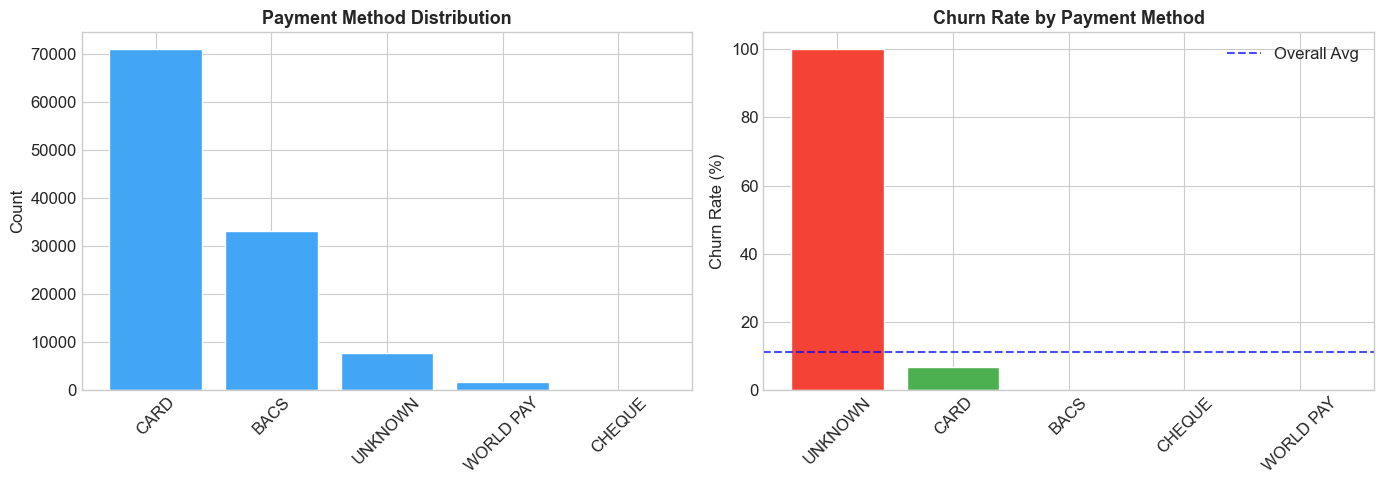

In [12]:
if 'payment_method' in billings.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution
    pm_counts = billings['payment_method'].value_counts()
    axes[0].bar(pm_counts.index, pm_counts.values, color='#42A5F5', edgecolor='white')
    axes[0].set_title('Payment Method Distribution', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Churn rate by payment method
    churn_by_pm = billings.groupby('payment_method')['is_churned'].mean().sort_values(ascending=False) * 100
    colors_pm = ['#F44336' if v > billings['is_churned'].mean() * 100 else '#4CAF50' for v in churn_by_pm.values]
    axes[1].bar(churn_by_pm.index, churn_by_pm.values, color=colors_pm, edgecolor='white')
    axes[1].set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Churn Rate (%)')
    axes[1].axhline(billings['is_churned'].mean() * 100, color='blue', linestyle='--', alpha=0.7, label='Overall Avg')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_payment_method.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10. Pricing Band Analysis

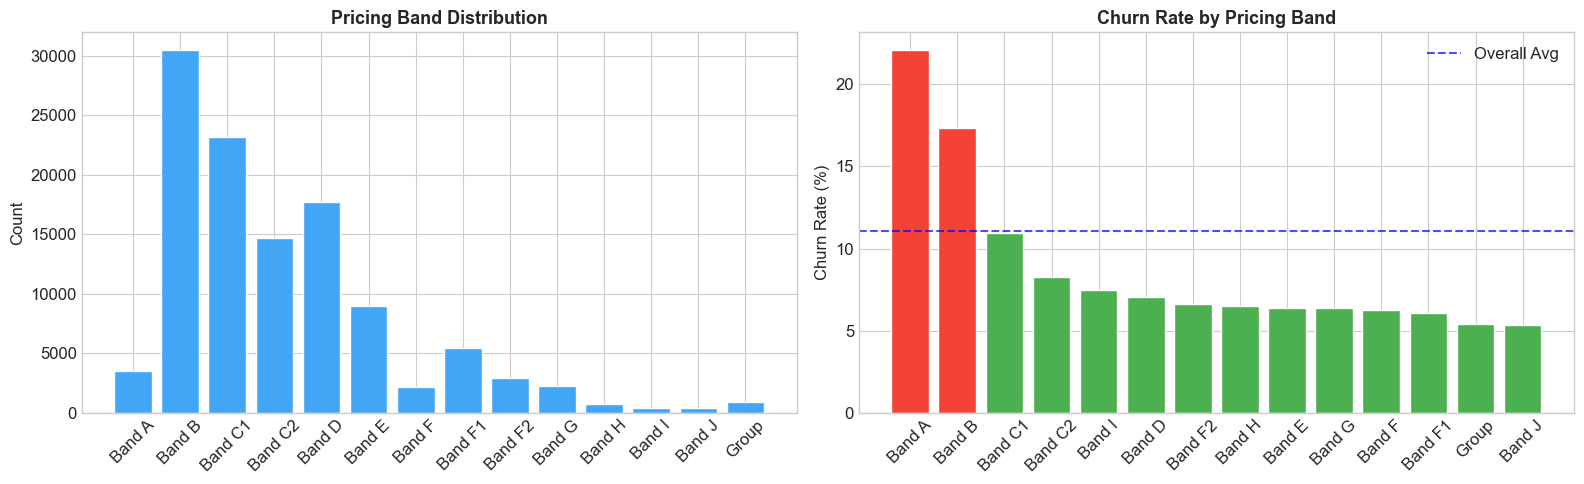

In [13]:
if 'band' in billings.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Distribution
    band_counts = billings['band'].value_counts().sort_index()
    axes[0].bar(band_counts.index, band_counts.values, color='#42A5F5', edgecolor='white')
    axes[0].set_title('Pricing Band Distribution', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Churn rate by band
    churn_by_band = billings.groupby('band')['is_churned'].mean().sort_values(ascending=False) * 100
    colors_band = ['#F44336' if v > billings['is_churned'].mean() * 100 else '#4CAF50' for v in churn_by_band.values]
    axes[1].bar(churn_by_band.index, churn_by_band.values, color=colors_band, edgecolor='white')
    axes[1].set_title('Churn Rate by Pricing Band', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Churn Rate (%)')
    axes[1].axhline(billings['is_churned'].mean() * 100, color='blue', linestyle='--', alpha=0.7, label='Overall Avg')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_band_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Tenure Analysis

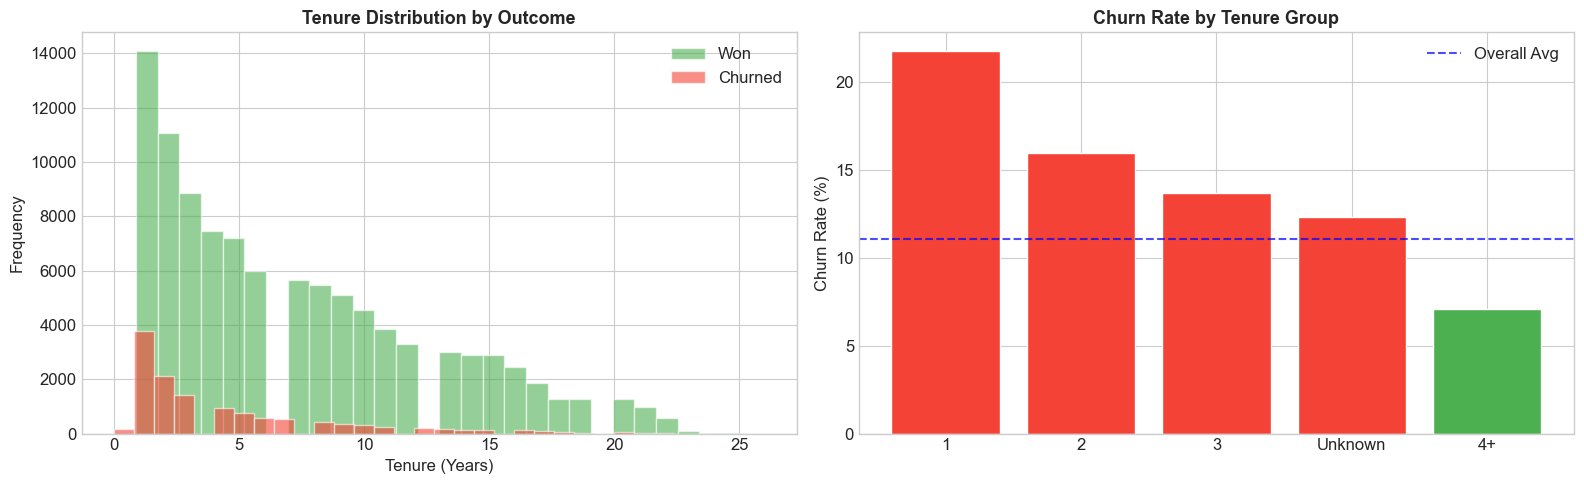

In [14]:
if 'tenure_years' in billings.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Tenure distribution by outcome
    billings[billings['prospect_outcome'] == 'Won']['tenure_years'].dropna().hist(
        bins=30, ax=axes[0], color='#4CAF50', alpha=0.6, label='Won', edgecolor='white')
    billings[billings['prospect_outcome'] == 'Churned']['tenure_years'].dropna().hist(
        bins=30, ax=axes[0], color='#F44336', alpha=0.6, label='Churned', edgecolor='white')
    axes[0].set_title('Tenure Distribution by Outcome', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Tenure (Years)')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    
    # Churn rate by tenure group
    if 'tenure_group' in billings.columns:
        churn_by_tenure = billings.groupby('tenure_group')['is_churned'].mean().sort_values(ascending=False) * 100
        colors_t = ['#F44336' if v > billings['is_churned'].mean() * 100 else '#4CAF50' for v in churn_by_tenure.values]
        axes[1].bar(churn_by_tenure.index, churn_by_tenure.values, color=colors_t, edgecolor='white')
        axes[1].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
        axes[1].set_ylabel('Churn Rate (%)')
        axes[1].axhline(billings['is_churned'].mean() * 100, color='blue', linestyle='--', alpha=0.7, label='Overall Avg')
        axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_tenure_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## 12. Renewal & Score Features Analysis

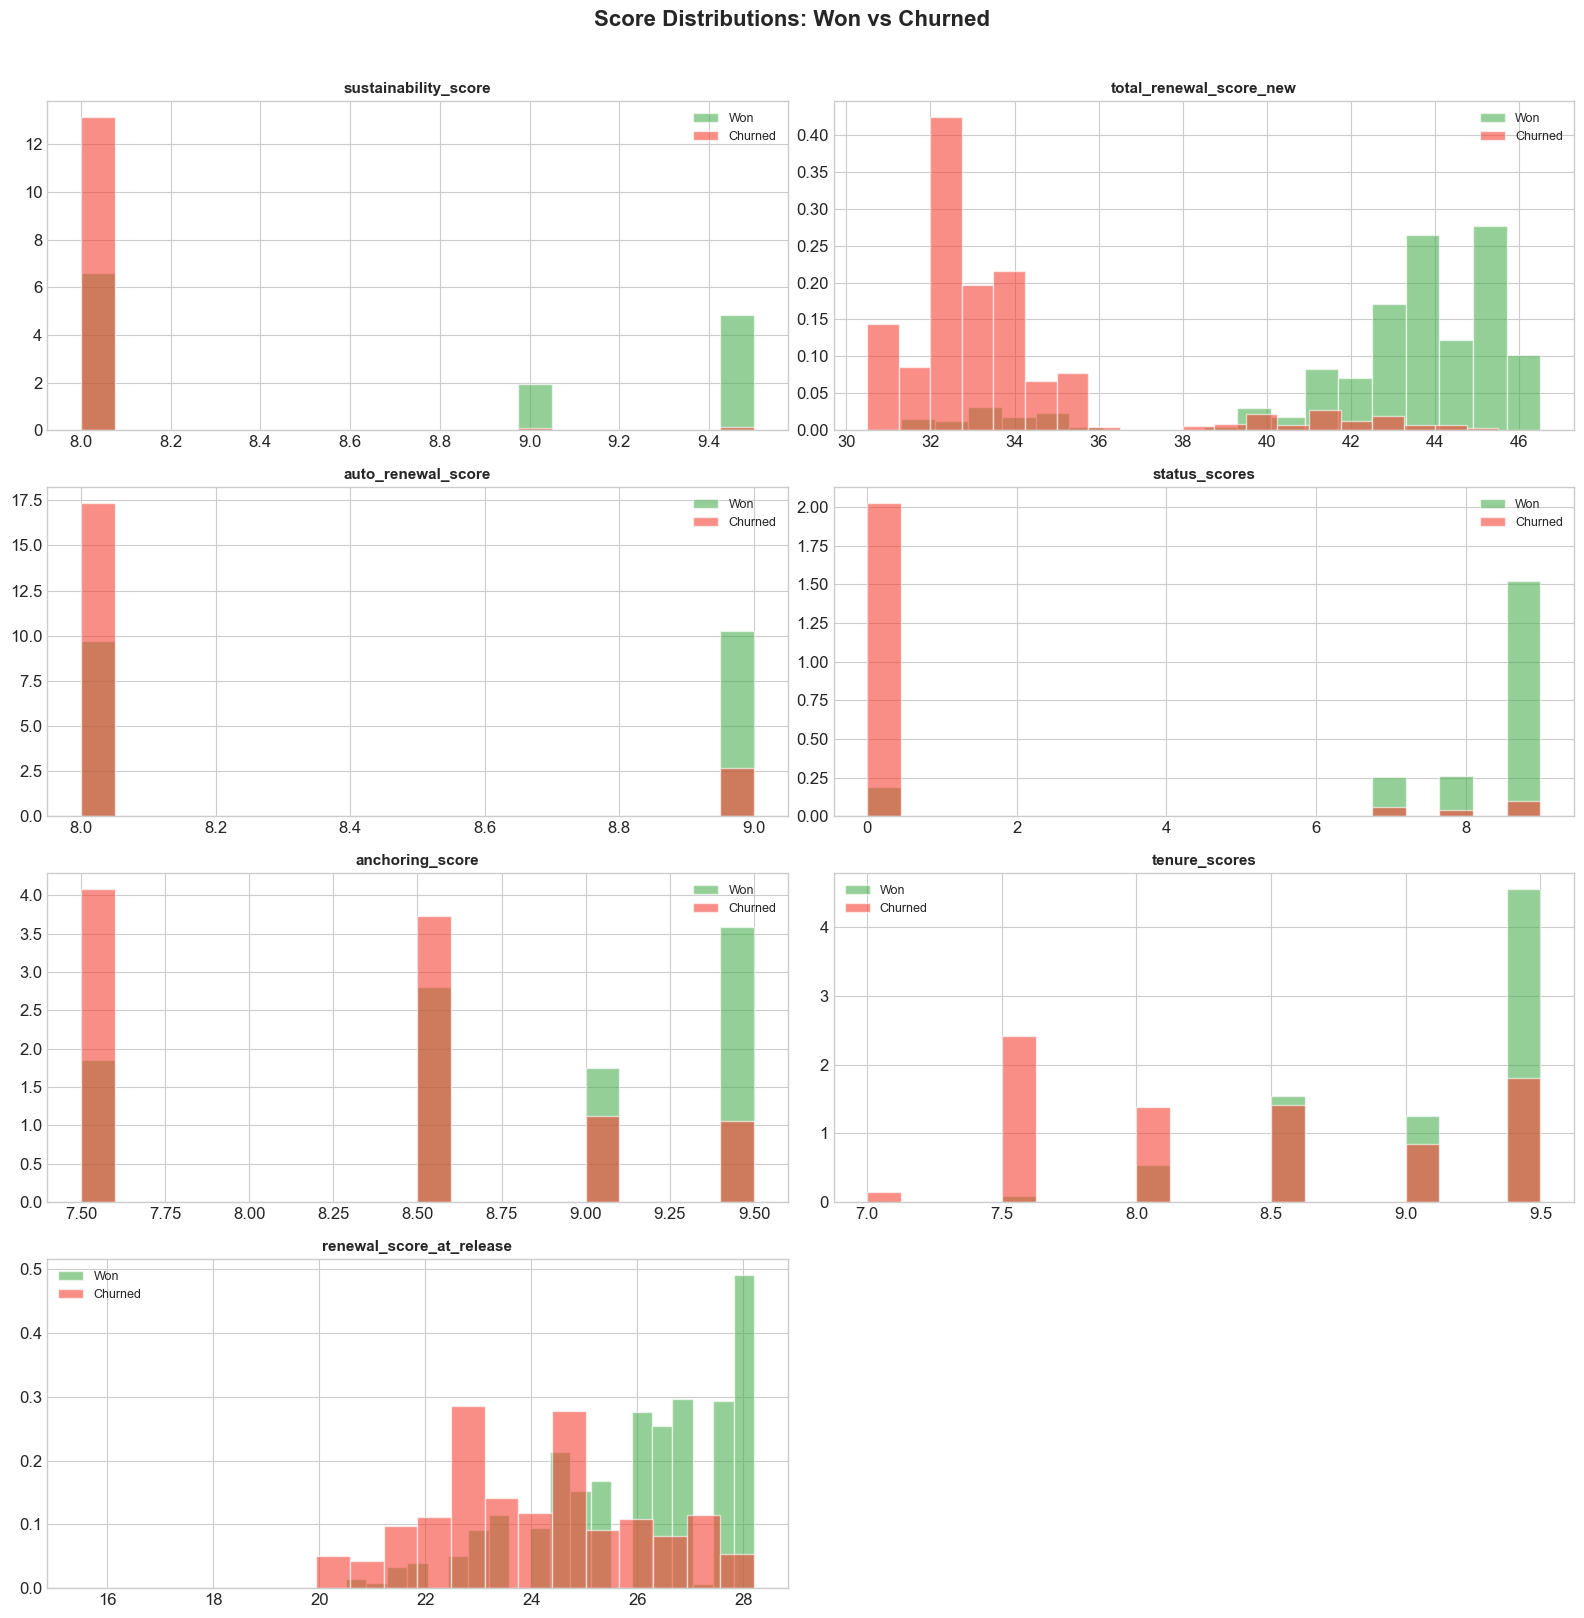

In [15]:
score_cols = ['sustainability_score', 'total_renewal_score_new', 'auto_renewal_score',
              'status_scores', 'anchoring_score', 'tenure_scores', 'renewal_score_at_release']
score_cols = [c for c in score_cols if c in billings.columns]

if score_cols:
    n = len(score_cols)
    fig, axes = plt.subplots((n + 1) // 2, 2, figsize=(16, 4 * ((n + 1) // 2)))
    axes = axes.flatten()
    
    for i, col in enumerate(score_cols):
        ax = axes[i]
        won_vals = billings[billings['prospect_outcome'] == 'Won'][col].dropna()
        churned_vals = billings[billings['prospect_outcome'] == 'Churned'][col].dropna()
        
        ax.hist(won_vals, bins=20, alpha=0.6, color='#4CAF50', label='Won', edgecolor='white', density=True)
        ax.hist(churned_vals, bins=20, alpha=0.6, color='#F44336', label='Churned', edgecolor='white', density=True)
        ax.set_title(f'{col}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Score Distributions: Won vs Churned', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_scores_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Auto-Renewal Flag Impact on Churn

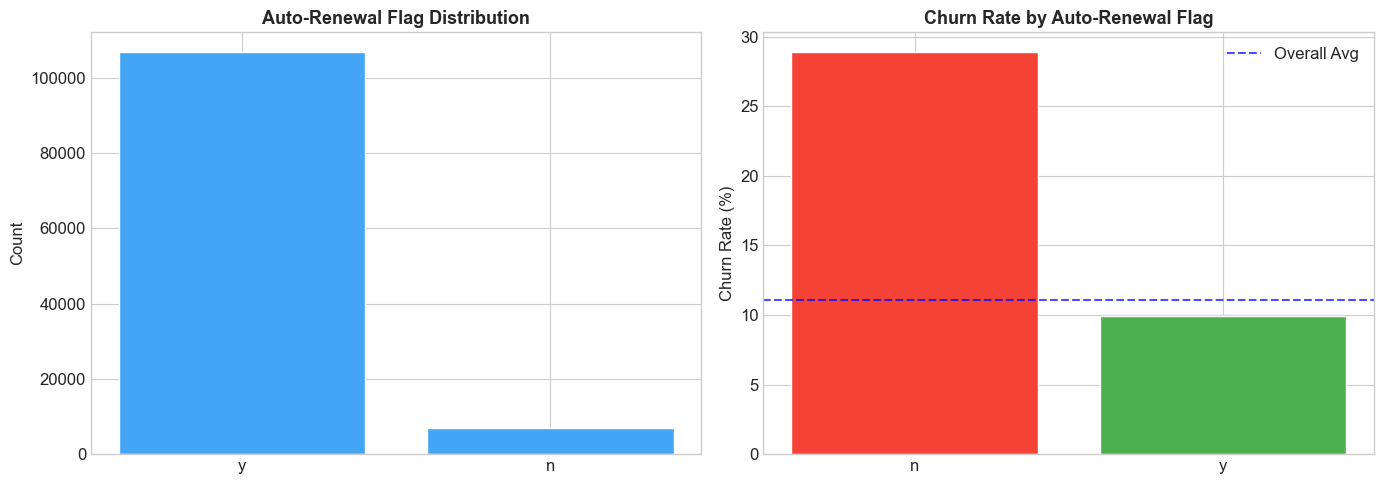

In [16]:
if 'current_auto_renewal_flag' in billings.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ar_counts = billings['current_auto_renewal_flag'].value_counts()
    axes[0].bar(ar_counts.index, ar_counts.values, color='#42A5F5', edgecolor='white')
    axes[0].set_title('Auto-Renewal Flag Distribution', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')
    
    churn_by_ar = billings.groupby('current_auto_renewal_flag')['is_churned'].mean() * 100
    colors_ar = ['#F44336' if v > billings['is_churned'].mean() * 100 else '#4CAF50' for v in churn_by_ar.values]
    axes[1].bar(churn_by_ar.index, churn_by_ar.values, color=colors_ar, edgecolor='white')
    axes[1].set_title('Churn Rate by Auto-Renewal Flag', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Churn Rate (%)')
    axes[1].axhline(billings['is_churned'].mean() * 100, color='blue', linestyle='--', alpha=0.7, label='Overall Avg')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_auto_renewal.png', dpi=150, bbox_inches='tight')
    plt.show()

## 14. Amount / Pricing Analysis

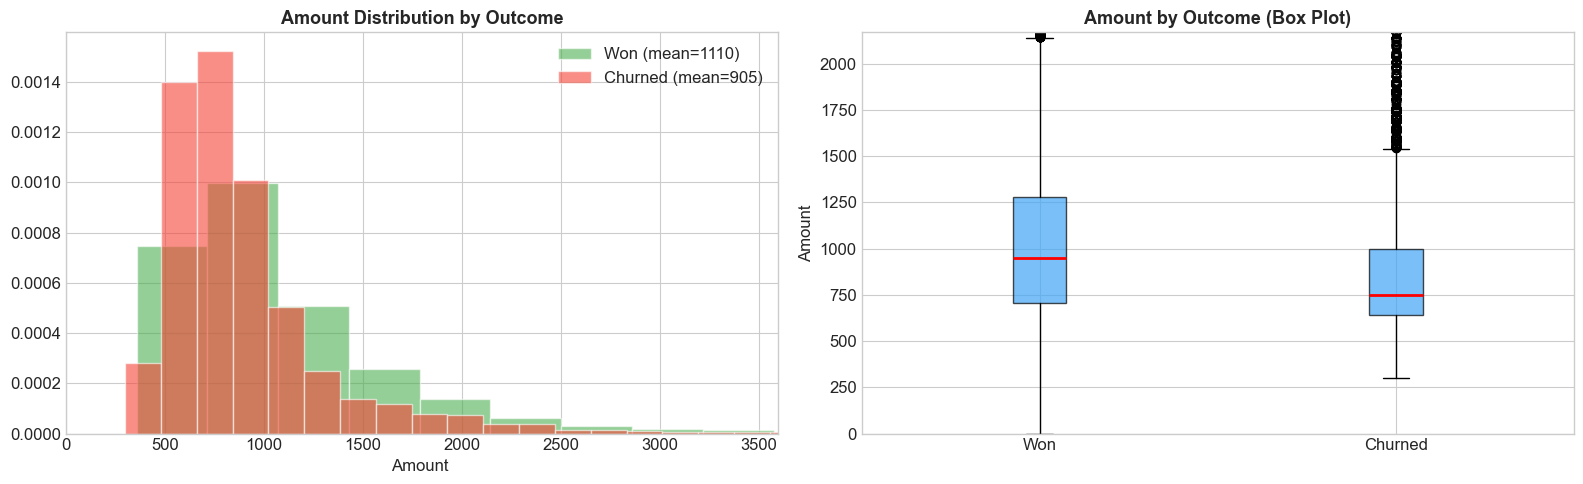

Average Amount - Won: 1110.00
Average Amount - Churned: 904.86
Median Amount - Won: 949.00
Median Amount - Churned: 749.00


In [17]:
if 'amount' in billings.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Distribution comparison
    won_amt = billings[billings['prospect_outcome'] == 'Won']['amount'].dropna()
    churned_amt = billings[billings['prospect_outcome'] == 'Churned']['amount'].dropna()
    
    axes[0].hist(won_amt, bins=50, alpha=0.6, color='#4CAF50', label=f'Won (mean={won_amt.mean():.0f})', edgecolor='white', density=True)
    axes[0].hist(churned_amt, bins=50, alpha=0.6, color='#F44336', label=f'Churned (mean={churned_amt.mean():.0f})', edgecolor='white', density=True)
    axes[0].set_title('Amount Distribution by Outcome', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Amount ')
    axes[0].legend()
    axes[0].set_xlim(0, billings['amount'].quantile(0.99))  # Trim outliers for visibility
    
    # Box plot comparison
    data_box = [won_amt, churned_amt]
    axes[1].boxplot(data_box, labels=['Won', 'Churned'], patch_artist=True,
                    boxprops=dict(facecolor='#42A5F5', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('Amount by Outcome (Box Plot)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Amount')
    axes[1].set_ylim(0, billings['amount'].quantile(0.95))
    
    plt.tight_layout()
    plt.savefig('../../reports/figures/billings_amount_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'Average Amount - Won: {won_amt.mean():.2f}')
    print(f'Average Amount - Churned: {churned_amt.mean():.2f}')
    print(f'Median Amount - Won: {won_amt.median():.2f}')
    print(f'Median Amount - Churned: {churned_amt.median():.2f}')

## 15. Key EDA Findings Summary

In [18]:
print('='*60)
print('BILLINGS EDA — KEY FINDINGS SUMMARY')
print('='*60)
print(f'\n1. Dataset Shape: {billings.shape[0]:,} rows x {billings.shape[1]} columns')
print(f'2. Overall Churn Rate: {billings["is_churned"].mean()*100:.1f}%')
print(f'3. Target Variable (prospect_outcome) is IMBALANCED:')
print(f'   - Won: {(billings["prospect_outcome"] == "Won").sum():,}')
print(f'   - Churned: {(billings["prospect_outcome"] == "Churned").sum():,}')
print(f'\n4. Top correlated features with churn:')
if 'churn_corr' in dir():
    for feat, corr_val in churn_corr.head(5).items():
        direction = '↑ increases churn' if corr_val > 0 else '↓ decreases churn'
        print(f'   - {feat}: r={corr_val:.3f} ({direction})')
print(f'\n5. Missing values: {billings.isnull().sum().sum()} total across all columns')
print(f'\n6. Key observations for churn modeling:')
print(f'   - Renewal scores, tenure, and auto-renewal status are likely strong predictors')
print(f'   - Payment method and pricing band show differential churn rates')
print(f'   - The class imbalance (~11% churn) should be addressed during modeling')
print('='*60)

BILLINGS EDA — KEY FINDINGS SUMMARY

1. Dataset Shape: 113,766 rows x 36 columns
2. Overall Churn Rate: 11.1%
3. Target Variable (prospect_outcome) is IMBALANCED:
   - Won: 101,174
   - Churned: 12,592

4. Top correlated features with churn:
   - total_renewal_score_new: r=-0.675 (↓ decreases churn)
   - status_scores: r=-0.672 (↓ decreases churn)
   - tenure_scores: r=-0.378 (↓ decreases churn)
   - renewal_score_at_release: r=-0.316 (↓ decreases churn)
   - sustainability_score: r=-0.303 (↓ decreases churn)

5. Missing values: 972 total across all columns

6. Key observations for churn modeling:
   - Renewal scores, tenure, and auto-renewal status are likely strong predictors
   - Payment method and pricing band show differential churn rates
   - The class imbalance (~11% churn) should be addressed during modeling
